In [14]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

In [15]:
market = ADatabase("market")

In [16]:
factors = [str(i) for i in range(10)]

In [17]:
market.connect()
prices = market.query("futures",{"ticker":"XRP-PERP-INTX"})
market.disconnect()

In [18]:
prices

,start,low,high,open,close,volume,ticker
0,1708653000,0.5412,0.5412,0.5412,0.5412,2391,XRP-PERP-INTX
1,1708652940,0.5412,0.5413,0.5413,0.5413,10770,XRP-PERP-INTX
2,1708652880,0.5412,0.5413,0.5412,0.5413,3751,XRP-PERP-INTX
3,1708652820,0.5411,0.5412,0.5412,0.5411,13844,XRP-PERP-INTX
4,1708652760,0.5412,0.5412,0.5412,0.5412,4535,XRP-PERP-INTX
...,...,...,...,...,...,...,...
153992,1694829840,0.5017,0.5017,0.5017,0.5017,390,XRP-PERP-INTX
153993,1694829780,0.5014,0.5016,0.5014,0.5016,6032,XRP-PERP-INTX
153994,1694829720,0.5013,0.5013,0.5013,0.5013,260,XRP-PERP-INTX
153995,1694829660,0.5011,0.5011,0.5011,0.5011,1812,XRP-PERP-INTX


In [19]:
prices["date"] = [datetime.fromtimestamp(float(x)) for x in prices["start"]]
prices.sort_values("date",inplace=True)
prices["close"] = [float(x) for x in prices["close"]]
prices["rolling"] = prices["close"].rolling(30).mean()
prices["rolling_mean"] = prices["close"].rolling(window=30).mean()
prices["rolling_std"] = prices["close"].rolling(window=30).std()
for i in range(10):
    prices[str(i)] = prices["close"].shift(i)
prices["y"] = prices["close"].shift(-5)
prices.dropna(inplace=True)
training = prices.iloc[:1000]
predictions = prices.iloc[1000:]
model1 = LinearRegression(fit_intercept=True)
model1.fit(training[factors],training["y"])
model2 = CatBoostRegressor(verbose=False)
model2.fit(training[factors],training["y"])
model3 = XGBRegressor(fit_intercept=True)
model3.fit(training[factors],training["y"])
predictions["prediction1"] =  model1.predict(predictions[factors])
predictions["prediction2"] =  model2.predict(predictions[factors])
predictions["prediction3"] =  model3.predict(predictions[factors])
predictions["prediction"] = (predictions["prediction1"] + predictions["prediction2"] + predictions["prediction3"]) / 3
prices = predictions[["date","rolling","rolling_mean","rolling_std","close","prediction"]].copy()

prices["return"] = prices["close"].pct_change()

## moving average
prices["signal"] = prices["rolling"] > prices["close"]

# ai
# prices["signal"] = prices["prediction"] > prices["close"]

# prices["signal"] = prices["rolling"] > prices["close"].rolling(30*2).mean()
prices["signal"] = [1 if x == True else - 1 for x in prices["signal"]]


# Calculate upper and lower Bollinger Bands
# prices["upper_band"] = prices["rolling_mean"] + 2 * prices["rolling_std"]
# prices["lower_band"] = prices["rolling_mean"] - 2 * prices["rolling_std"]
# prices["signal"] = 0  # 0 indicates no signal initially
# prices.loc[prices["close"] < prices["lower_band"], "signal"] = 1
# prices.loc[prices["close"] > prices["upper_band"], "signal"] = -1
# prices["signal"] = prices["signal"].replace(0, method="ffill")
# prices.drop(["rolling_mean", "rolling_std", "upper_band", "lower_band"], axis=1, inplace=True)

C:\Users\eric\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:38:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "fit_intercept" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\eric\AppData\Local\Temp\ipykernel_13900\383843699.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions["prediction1"] =  model1.predict(predictions[factors])
C:\Users\eric\AppData\Local\Temp\ipykernel_13900\383843699.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [20]:
prices

,date,rolling,rolling_mean,rolling_std,close,prediction,return,signal
152967,2023-09-18 10:04:00,0.489887,0.489887,0.000690,0.4892,0.489905,NaN,1
152966,2023-09-18 10:05:00,0.489887,0.489887,0.000690,0.4893,0.489936,0.000204,1
152965,2023-09-18 10:06:00,0.489907,0.489907,0.000663,0.4893,0.489946,0.000000,1
152964,2023-09-18 10:07:00,0.489903,0.489903,0.000666,0.4892,0.489774,-0.000204,1
152963,2023-09-18 10:09:00,0.489940,0.489940,0.000627,0.4898,0.489746,0.001226,1
...,...,...,...,...,...,...,...,...
9,2024-02-23 10:41:00,0.542437,0.542437,0.000574,0.5423,0.514016,-0.000184,1
8,2024-02-23 10:42:00,0.542390,0.542390,0.000532,0.5422,0.513973,-0.000184,1
7,2024-02-23 10:43:00,0.542350,0.542350,0.000506,0.5421,0.513939,-0.000184,1
6,2024-02-23 10:44:00,0.542300,0.542300,0.000493,0.5417,0.513828,-0.000738,1


  1%|█                                                                                                     | 1658/152963 [00:00<01:12, 2088.87it/s]

can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar


 28%|████████████████████████████▌                                                                        | 43221/152963 [00:21<00:55, 1965.76it/s]

can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar


 29%|████████████████████████████▊                                                                        | 43605/152963 [00:21<01:03, 1718.61it/s]

...

 63%|███████████████████████████████████████████████████████████████▉                                     | 96850/152963 [00:47<00:26, 2096.05it/s]

can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar


 82%|██████████████████████████████████████████████████████████████████████████████████▎                 | 125865/152963 [01:02<00:13, 2062.57it/s]

can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar
can only convert an array of size 1 to a Python scalar


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 152963/152963 [01:15<00:00, 2017.30it/s]


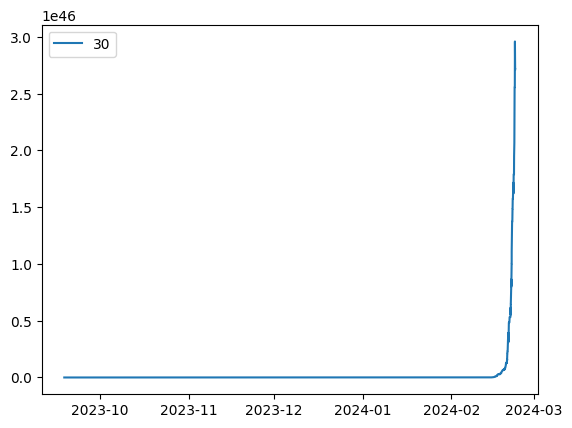

In [21]:
profittake = 0.004
stoploss = 0.001
deadpoint = 0.003
leverage = 15
callback = 0.001
states = []
df = prices.copy()
state = {
"filled":False,
"signal":0,
"buy_price":0,
"sell_price":0
}
for date in tqdm(df["date"]):
    try:
        current_market = df[df["date"]==date] 
        current_price = current_market["close"].item()
        asset_return = current_market["return"].item()
        signal = current_market["signal"].item()
        if state["filled"]==False:
            state["signal"] = signal
            state["buy_price"] = current_price
            state["sell_price"] = current_price
            state["buy_date"] = date
            state["filled"] = True
            state["leverage"] = leverage
        else:
            returns = state["signal"] * (current_price - state["buy_price"]) / state["buy_price"]
            if (asset_return * state["signal"] < -callback and returns > profittake) or returns <-deadpoint:
                state["sell_price"] = current_price
                state["sell_date"] = date
                states.append(state.copy())
                state = {
                    "filled":False,
                    "signal":0,
                    "buy_price":0,
                    "sell_price":0
                }
            elif returns <= -stoploss:
                state["sell_price"] = state["buy_price"]
                state["sell_date"] = date
                states.append(state.copy())
                state = {
                    "filled":False,
                    "signal":0,
                    "buy_price":0,
                    "sell_price":0
                }
    except Exception as e:
        print(str(e))
        continue
trades = pd.DataFrame(states)
trades["return"] = ((trades["sell_price"] - trades["buy_price"]) / trades["buy_price"] * leverage * trades["signal"] + 1)
trades = trades[trades["return"]>0]
trades["cr"] = trades["return"].cumprod()
plt.plot(trades["sell_date"].values,trades["cr"].values)
plt.legend([30,50])
plt.show()

In [22]:
trades.sort_values("return",ascending=True).head(10)

,filled,signal,buy_price,sell_price,buy_date,leverage,sell_date,return,cr
3673,True,1,0.6305,0.5925,2023-12-04 20:11:00,15,2023-12-04 20:12:00,0.095956,5.357032e+19
2160,True,1,0.7059,0.6674,2023-11-07 09:30:00,15,2023-11-07 09:33:00,0.181895,2.630997e+12
2472,True,1,0.6734,0.6409,2023-11-10 01:11:00,15,2023-11-10 01:12:00,0.276062,1.890074e+14
2805,True,-1,0.6702,0.6989,2023-11-14 05:46:00,15,2023-11-14 05:47:00,0.357654,1.110276e+16
2806,True,-1,0.6945,0.7180,2023-11-14 05:48:00,15,2023-11-14 05:49:00,0.492441,5.467448e+15
1236,True,1,0.5555,0.5396,2023-10-25 00:38:00,15,2023-10-25 00:39:00,0.570657,1.141583e+07
5735,True,-1,0.5603,0.5763,2024-01-11 00:50:00,15,2024-01-11 00:57:00,0.571658,3.677322e+33
5186,True,1,0.5571,0.5438,2024-01-03 21:31:00,15,2024-01-03 21:32:00,0.641896,8.674223e+29
642,True,1,0.5073,0.4967,2023-10-09 18:02:00,15,2023-10-09 18:49:00,0.686576,7.589696e+03
5986,True,1,0.5683,0.5573,2024-01-13 07:20:00,15,2024-01-13 07:21:00,0.709660,9.915541e+34


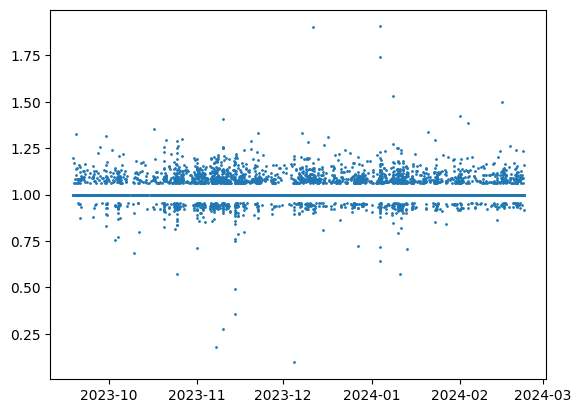

In [23]:
plt.scatter(trades["sell_date"],trades["return"],s=1)
plt.show()